# Peningkatan Akurasi Sistem Rekomendasi Multi-Kriteria
## melalui Modifikasi Recurrent Naive Bayes dan Random Forest
**Tugas Akhir – Taura Muhammad Sanubari (103012330280)**  



## Bagian 0 – Import Library

In [1]:
# BAGIAN 0 – IMPORT LIBRARY
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product
from copy import deepcopy

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, f1_score,
                              precision_score, recall_score,
                              classification_report)

import os, random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Semua library berhasil di-import.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


Semua library berhasil di-import.
   pandas  : 2.3.1
   numpy   : 2.3.2


## Bagian 1 – Load Dataset

In [2]:
# BAGIAN 1 – LOAD DATA

OPENTABLE_PATH = "datasets/opentable/opentable_cleaned.csv"
ITMREC_PATH    = "datasets/itmrec/ratings.csv"

# OpenTable
df_ot_raw = pd.read_csv(OPENTABLE_PATH)
df_ot_raw.rename(columns={"uid": "UserID"}, inplace=True)
OT_CRITERIA = ["Food", "Service", "Ambience", "Value"]
OT_USER_COL = "UserID"
OT_ITEM_COL = "ItemID"
OT_RATING   = "Rating"

# ITMRec 
df_it_raw = (pd.read_csv(ITMREC_PATH)
               [["UserID","Item","Rating","App","Data","Ease"]]
               .dropna()
               .rename(columns={"Item": "ItemID"})
               .reset_index(drop=True))
IT_CRITERIA = ["App", "Data", "Ease"]
IT_USER_COL = "UserID"
IT_ITEM_COL = "ItemID"
IT_RATING   = "Rating"

for name, df, crit in [("OpenTable", df_ot_raw, OT_CRITERIA),
                        ("ITMRec",   df_it_raw, IT_CRITERIA)]:
    print(f"{'='*52}")
    print(f"  {name}  |  shape: {df.shape}")
    print(f"  Kriteria: {crit}")
    print(f"  Missing :\n{df[crit].isnull().sum().to_string()}")
print("\n Dataset berhasil dimuat.")


  OpenTable  |  shape: (6366, 7)
  Kriteria: ['Food', 'Service', 'Ambience', 'Value']
  Missing :
Food        0
Service     0
Ambience    0
Value       0
  ITMRec  |  shape: (5228, 6)
  Kriteria: ['App', 'Data', 'Ease']
  Missing :
App     0
Data    0
Ease    0

 Dataset berhasil dimuat.


## Bagian 2 – Simulasi Partial Preference (MAR)
Karena dataset asli hampir lengkap, kita mensimulasikan **Missing At Random (MAR)**
dengan menyembunyikan 30% nilai kriteria secara acak. `mask` menyimpan lokasi nilai yang disembunyikan
sehingga kita bisa menghitung MAE imputasi secara tepat.


In [3]:
# BAGIAN 2 – SIMULASI PARTIAL PREFERENCE (MAR)

def simulate_partial_preference(df, criteria_cols, missing_rate=0.30, seed=42):
    """
    Sembunyikan `missing_rate` proporsi nilai pada setiap kolom kriteria.
    Kembalikan df_masked (dengan NaN) dan mask (True = posisi yang disembunyikan).
    """
    rng      = np.random.default_rng(seed)
    df_masked = df.copy()
    mask      = pd.DataFrame(False, index=df.index, columns=criteria_cols)

    for col in criteria_cols:
        n_miss   = int(len(df) * missing_rate)
        miss_idx = rng.choice(df.index, size=n_miss, replace=False)
        df_masked.loc[miss_idx, col] = np.nan
        mask.loc[miss_idx, col]      = True

    return df_masked, mask


MISSING_RATE = 0.30

df_ot,  mask_ot = simulate_partial_preference(df_ot_raw, OT_CRITERIA, MISSING_RATE, SEED)
df_it,  mask_it = simulate_partial_preference(df_it_raw, IT_CRITERIA, MISSING_RATE, SEED)

for name, df, crit in [("OpenTable", df_ot, OT_CRITERIA),
                        ("ITMRec",   df_it, IT_CRITERIA)]:
    total   = len(df) * len(crit)
    missing = df[crit].isnull().sum().sum()
    print(f"[{name}]  Total sel: {total:,}  |  Missing: {missing:,}  ({missing/total*100:.1f}%)")

print("\n Simulasi selesai.")


[OpenTable]  Total sel: 25,464  |  Missing: 7,636  (30.0%)
[ITMRec]  Total sel: 15,684  |  Missing: 4,704  (30.0%)

 Simulasi selesai.


## Bagian 3 – Pra-Pemrosesan & Sparsity

$$S_c = 1 - \frac{|R_c|}{|U| \times |I|}$$

Kriteria dengan **sparsity terendah** (paling padat) diimputasi **lebih awal** oleh RNB.


OPENTABLE – Sparsity per Kriteria:
Kriteria  |Rc|  |U|×|I|  Sparsity (Sc)
    Food  4457   119119         0.9626
 Service  4457   119119         0.9626
Ambience  4457   119119         0.9626
   Value  4457   119119         0.9626

ITMREC – Sparsity per Kriteria:
Kriteria  |Rc|  |U|×|I|  Sparsity (Sc)
     App  3660    31780         0.8848
    Data  3660    31780         0.8848
    Ease  3660    31780         0.8848

Urutan imputasi OpenTable : ['Food', 'Service', 'Ambience', 'Value']
Urutan imputasi ITMRec    : ['App', 'Data', 'Ease']


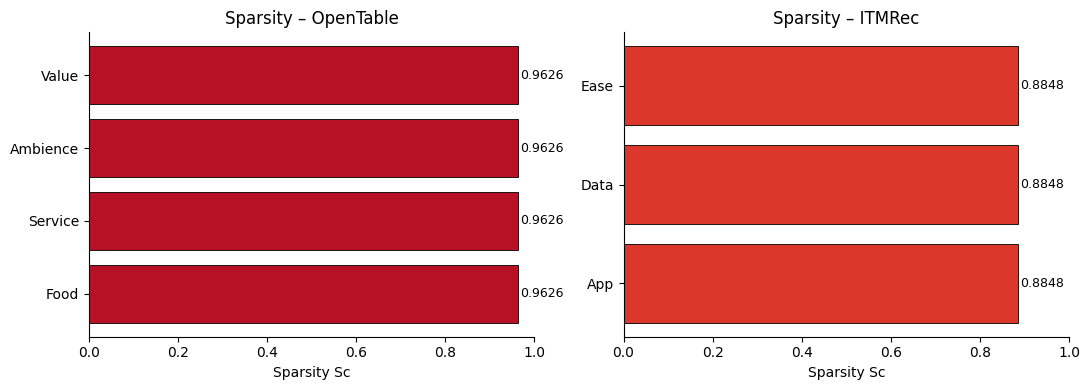

In [4]:
# BAGIAN 3 – PERHITUNGAN SPARSITY & PENGURUTAN KRITERIA

def compute_sparsity(df, user_col, item_col, criteria_cols):
    """
    Hitung sparsity Sc per kriteria dan kembalikan DataFrame
    yang diurutkan dari sparsity terendah (paling padat).
    """
    n_u   = df[user_col].nunique()
    n_i   = df[item_col].nunique()
    total = n_u * n_i
    rows  = []
    for col in criteria_cols:
        rc = df[col].notna().sum()
        sc = 1 - rc / total
        rows.append({"Kriteria": col, "|Rc|": rc,
                     "|U|×|I|": total, "Sparsity (Sc)": round(sc, 4)})
    return pd.DataFrame(rows).sort_values("Sparsity (Sc)").reset_index(drop=True)


sp_ot = compute_sparsity(df_ot, OT_USER_COL, OT_ITEM_COL, OT_CRITERIA)
sp_it = compute_sparsity(df_it, IT_USER_COL, IT_ITEM_COL, IT_CRITERIA)

print("OPENTABLE – Sparsity per Kriteria:")
print(sp_ot.to_string(index=False))
print()
print("ITMREC – Sparsity per Kriteria:")
print(sp_it.to_string(index=False))

order_ot = sp_ot["Kriteria"].tolist()
order_it = sp_it["Kriteria"].tolist()
print(f"\nUrutan imputasi OpenTable : {order_ot}")
print(f"Urutan imputasi ITMRec    : {order_it}")

# ── Visualisasi ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sp_df, title in [(axes[0], sp_ot, "OpenTable"),
                          (axes[1], sp_it, "ITMRec")]:
    vals   = sp_df["Sparsity (Sc)"]
    colors = plt.cm.RdYlGn_r(vals / 1.0)
    bars   = ax.barh(sp_df["Kriteria"], vals, color=colors, edgecolor="black", lw=0.6)
    for b, v in zip(bars, vals):
        ax.text(v + 0.005, b.get_y() + b.get_height()/2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.set_xlabel("Sparsity Sc"); ax.set_title(f"Sparsity – {title}")
    ax.set_xlim(0, 1); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("sparsity.png", dpi=120); plt.show()


## Bagian 4 – Recurrent Naive Bayes + Confidence Thresholding

### Aturan keputusan:
$$\hat{y}_c = \begin{cases}\text{Prediksi RNB} & \text{jika } P(y|x) \geq \theta \text{ (dan ada fitur)}\\\text{Mean kriteria} & \text{jika } P(y|x) < \theta \text{ atau tidak ada fitur}\end{cases}$$

**Catatan penting:** Kriteria *pertama* dalam urutan tidak memiliki fitur sebelumnya,
sehingga selalu menggunakan mean (terlepas dari θ). Ini adalah perilaku yang **benar**
secara algoritma dan *bukan* bug.


In [5]:
# BAGIAN 4 – KELAS RecurrentNaiveBayes (RNB + Thresholding)

class RecurrentNaiveBayes:
    """
    Implementasi Recurrent Naive Bayes untuk imputasi preferensi parsial
    pada Sistem Rekomendasi Multi-Kriteria (MCRS).
    
    Mekanisme:
    1. Urutkan kriteria berdasarkan sparsity terendah.
    2. Kriteria pertama → imputasi dengan mean (tidak ada fitur sebelumnya).
    3. Kriteria ke-k → gunakan CategoricalNB dengan kriteria 1..(k-1) sebagai fitur.
    4. Confidence Thresholding: tolak prediksi jika max(P(y|x)) < θ → ganti mean.
    """

    def __init__(self, criteria_order, theta=0.0, rating_min=1, rating_max=5):
        self.criteria_order = criteria_order
        self.theta          = theta
        self.rating_min     = rating_min
        self.rating_max     = rating_max
        self.models_        = {}
        self.encoders_      = {}
        self.means_         = {}
        self._accepted_pct  = {}

    # ── fit ─────────────────────────────────────────────────
    def fit(self, df_train):
        df = df_train[self.criteria_order].copy()
        for col in self.criteria_order:
            self.means_[col] = round(df[col].mean())  # integer untuk prediksi diskrit

        already = []
        for col in self.criteria_order:
            if not already:
                # Kriteria pertama: tidak ada fitur → pakai mean saja
                self.models_[col]   = None
                self.encoders_[col] = None
            else:
                # Baris yang lengkap: target dan semua fitur ada
                complete = df[already + [col]].dropna()
                if len(complete) < 10:
                    self.models_[col]   = None
                    self.encoders_[col] = None
                else:
                    X = complete[already].values
                    y = complete[col].values.astype(int)
                    cats = [list(range(self.rating_min, self.rating_max + 1))] * len(already)
                    enc = OrdinalEncoder(categories=cats,
                                         handle_unknown="use_encoded_value",
                                         unknown_value=-1)
                    X_enc = enc.fit_transform(X).astype(int)
                    nb    = CategoricalNB(min_categories=self.rating_max - self.rating_min + 1)
                    nb.fit(X_enc, y)
                    self.models_[col]   = nb
                    self.encoders_[col] = enc
            already.append(col)
        return self

    # transform
    def transform(self, df_input):
        """Imputasi NaN pada df_input; kembalikan DataFrame tanpa NaN di kolom kriteria."""
        df = df_input[self.criteria_order].copy().astype(float)

        already = []
        for col in self.criteria_order:
            missing_mask = df[col].isna()
            n_missing    = missing_mask.sum()
            n_accepted   = 0

            if n_missing > 0:
                model = self.models_.get(col)
                enc   = self.encoders_.get(col)
                fallback = float(self.means_.get(col, 3))

                if model is None or enc is None or not already:
                    # Tidak ada model atau kriteria pertama → mean
                    df.loc[missing_mask, col] = fallback
                else:
                    for idx in df[missing_mask].index:
                        row_feat = df.loc[idx, already].values
                        if np.any(np.isnan(row_feat)):
                            df.loc[idx, col] = fallback
                            continue
                        try:
                            X_enc = enc.transform(row_feat.reshape(1, -1)).astype(int)
                            X_enc = np.clip(X_enc, 0, self.rating_max - self.rating_min)
                            proba = model.predict_proba(X_enc)[0]
                            max_p = proba.max()
                            pred  = model.classes_[np.argmax(proba)]
                            # ─── CONFIDENCE THRESHOLDING ──────────────
                            if max_p >= self.theta:
                                df.loc[idx, col] = int(pred)
                                n_accepted += 1
                            else:
                                df.loc[idx, col] = fallback  # tolak → mean
                        except Exception:
                            df.loc[idx, col] = fallback

            pct = (n_accepted / n_missing * 100) if n_missing > 0 else 0.0
            self._accepted_pct[col] = pct
            already.append(col)

        return df

    def fit_transform(self, df_train, df_test=None):
        self.fit(df_train)
        return self.transform(df_test if df_test is not None else df_train)

    def acceptance_summary(self):
        print(f"  [RNB θ={self.theta}] Acceptance rate per kriteria:")
        for col, pct in self._accepted_pct.items():
            bar = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
            label = "(no features → mean)" if pct == 0.0 and col == self.criteria_order[0] else ""
            print(f"    {col:12s}: {bar} {pct:5.1f}% {label}")


print("Kelas RecurrentNaiveBayes berhasil didefinisikan.")


Kelas RecurrentNaiveBayes berhasil didefinisikan.


## Bagian 5 – RSVD dari Scratch (Matrix Factorization + SGD)

Implementasi ini **menggantikan scikit-surprise** agar bisa berjalan di semua environment.
Algoritma menggunakan **Stochastic Gradient Descent (SGD)** untuk mengoptimasi fungsi loss:

$$\mathcal{L} = \sum_{(u,i) \in R} \left(r_{ui} - \mu - b_u - b_i - \mathbf{p}_u^T \mathbf{q}_i\right)^2 + \lambda\left(\|\mathbf{p}_u\|^2 + \|\mathbf{q}_i\|^2 + b_u^2 + b_i^2\right)$$

**GridSearch manual** dijalankan pada:
- `n_factors`: 20, 50, 100  
- `lr`: 0.005, 0.01  
- `reg`: 0.02, 0.05, 0.10


In [6]:
# BAGIAN 5 – RSVD FROM SCRATCH (tanpa scikit-surprise)

class MatrixFactorizationSVD:
    """
    Regularized Matrix Factorization (SVD-style) dengan SGD.
    Sesuai dengan implementasi standar pada Koren et al. (2009).
    
    Model: r_hat(u,i) = mu + b_u + b_i + p_u @ q_i
    
    Parameters
    ----------
    n_factors  : dimensi faktor laten
    lr         : learning rate SGD
    reg        : koefisien regularisasi L2
    n_epochs   : jumlah epoch training
    rating_min : nilai minimum rating
    rating_max : nilai maksimum rating
    """

    def __init__(self, n_factors=50, lr=0.005, reg=0.05,
                 n_epochs=30, rating_min=1, rating_max=5, seed=42):
        self.n_factors  = n_factors
        self.lr         = lr
        self.reg        = reg
        self.n_epochs   = n_epochs
        self.r_min      = rating_min
        self.r_max      = rating_max
        self.seed       = seed

    def fit(self, user_ids, item_ids, ratings):
        """
        Latih model dari array user_ids, item_ids, ratings.
        Semua ID akan di-encode ke integer internal.
        """
        rng = np.random.default_rng(self.seed)

        # Encode ID ke integer berurutan
        self.u_enc_ = {u: i for i, u in enumerate(np.unique(user_ids))}
        self.i_enc_ = {v: i for i, v in enumerate(np.unique(item_ids))}
        n_u = len(self.u_enc_)
        n_i = len(self.i_enc_)

        u_idx = np.array([self.u_enc_[u] for u in user_ids])
        i_idx = np.array([self.i_enc_[i] for i in item_ids])
        r     = np.array(ratings, dtype=float)

        self.mu_ = r.mean()

        # Inisialisasi parameter
        self.P_  = rng.normal(0, 0.01, (n_u, self.n_factors))
        self.Q_  = rng.normal(0, 0.01, (n_i, self.n_factors))
        self.bu_ = np.zeros(n_u)
        self.bi_ = np.zeros(n_i)

        # SGD training
        indices = np.arange(len(r))
        for epoch in range(self.n_epochs):
            rng.shuffle(indices)
            for idx in indices:
                u, i, rui = u_idx[idx], i_idx[idx], r[idx]
                pred = (self.mu_ + self.bu_[u] + self.bi_[i]
                        + self.P_[u] @ self.Q_[i])
                err  = rui - pred
                # Update
                pu_old = self.P_[u].copy()
                qi_old = self.Q_[i].copy()
                self.bu_[u] += self.lr * (err - self.reg * self.bu_[u])
                self.bi_[i] += self.lr * (err - self.reg * self.bi_[i])
                self.P_[u]  += self.lr * (err * qi_old - self.reg * pu_old)
                self.Q_[i]  += self.lr * (err * pu_old - self.reg * qi_old)
        return self

    def predict(self, user_id, item_id):
        """Prediksi rating untuk satu pasangan (user, item)."""
        u = self.u_enc_.get(user_id)
        i = self.i_enc_.get(item_id)
        if u is None or i is None:
            return self.mu_  # cold-start → global mean
        est = self.mu_ + self.bu_[u] + self.bi_[i] + self.P_[u] @ self.Q_[i]
        return float(np.clip(est, self.r_min, self.r_max))

    def predict_batch(self, user_ids, item_ids):
        """Prediksi batch; kembalikan array float."""
        return np.array([self.predict(u, i)
                         for u, i in zip(user_ids, item_ids)])


def cv_mae_mf(user_ids, item_ids, ratings, params, n_splits=3, seed=42):
    """
    Cross-validation sederhana untuk MatrixFactorizationSVD.
    Kembalikan rata-rata MAE dari n_splits fold.
    """
    indices = np.arange(len(ratings))
    np.random.seed(seed)
    np.random.shuffle(indices)
    folds = np.array_split(indices, n_splits)
    maes  = []
    for k in range(n_splits):
        val_idx   = folds[k]
        train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != k])
        mf = MatrixFactorizationSVD(**params, seed=seed)
        mf.fit(user_ids[train_idx], item_ids[train_idx], ratings[train_idx])
        preds = mf.predict_batch(user_ids[val_idx], item_ids[val_idx])
        maes.append(mean_absolute_error(ratings[val_idx], preds))
    return np.mean(maes)


def train_rsvd_per_criterion(df_imp, user_col, item_col, criteria_cols,
                              rating_scale=(1, 5)):
    """
    Latih MatrixFactorizationSVD per kriteria dengan GridSearch manual.
    
    Hyperparameter yang dicari:
      n_factors : [20, 50, 100]
      lr        : [0.005, 0.01]
      reg       : [0.02, 0.05, 0.10]
    """
    param_grid = list(ParameterGrid({
        "n_factors": [20, 50, 100],
        "lr"       : [0.005, 0.01],
        "reg"      : [0.02, 0.05, 0.10],
        "n_epochs" : [25],
        "rating_min": [rating_scale[0]],
        "rating_max": [rating_scale[1]],
    }))

    best_models = {}
    best_params = {}

    for col in criteria_cols:
        print(f"GridSearch RSVD untuk kriteria [{col}] "
              f"({len(param_grid)} kombinasi × 3-fold CV) ...")
        df_col = df_imp[[user_col, item_col, col]].dropna()
        u_arr  = df_col[user_col].values
        i_arr  = df_col[item_col].values
        r_arr  = df_col[col].values.astype(float)

        best_mae, best_p = np.inf, None
        for params in param_grid:
            mae = cv_mae_mf(u_arr, i_arr, r_arr, params, n_splits=3, seed=SEED)
            if mae < best_mae:
                best_mae, best_p = mae, params

        # Latih ulang pada seluruh data dengan parameter terbaik
        final_model = MatrixFactorizationSVD(**best_p, seed=SEED)
        final_model.fit(u_arr, i_arr, r_arr)
        best_models[col] = final_model
        best_params[col] = {k: v for k, v in best_p.items()
                            if k in ["n_factors","lr","reg"]}
        print(f"     Best CV-MAE: {best_mae:.4f}  |  Params: {best_params[col]}")

    return best_models, best_params


def predict_criteria_rsvd(df_test_users_items, user_col, item_col,
                           criteria_cols, best_models):
    """
    Prediksi nilai kriteria untuk setiap baris di df_test_users_items
    menggunakan model RSVD yang sudah dilatih.
    Hasilnya adalah rating diskrit (dibulatkan ke integer 1-5).
    """
    df_pred = df_test_users_items[[user_col, item_col]].copy().reset_index(drop=True)
    for col in criteria_cols:
        model = best_models[col]
        preds = model.predict_batch(df_pred[user_col].values,
                                     df_pred[item_col].values)
        df_pred[col] = np.clip(np.round(preds), 1, 5).astype(int)
    return df_pred


print("RSVD (MatrixFactorization + SGD) dan fungsi GridSearch siap.")


RSVD (MatrixFactorization + SGD) dan fungsi GridSearch siap.


## Bagian 6 – Tuning Confidence Threshold (θ)


  OpenTable
  θ=0.70  →  MAE imputasi: 0.6955  | Food:0.930 Service:0.656 Ambience:0.596 Value:0.599
  θ=0.75  →  MAE imputasi: 0.6996  | Food:0.930 Service:0.656 Ambience:0.596 Value:0.616
  θ=0.80  →  MAE imputasi: 0.6996  | Food:0.930 Service:0.656 Ambience:0.596 Value:0.616
  θ=0.85  →  MAE imputasi: 0.6996  | Food:0.930 Service:0.656 Ambience:0.596 Value:0.616
  θ=0.90  →  MAE imputasi: 0.8703  | Food:0.930 Service:0.980 Ambience:0.844 Value:0.728

  ITMRec
  θ=0.70  →  MAE imputasi: 1.0125  | App:1.170 Data:1.072 Ease:0.796
  θ=0.75  →  MAE imputasi: 1.0125  | App:1.170 Data:1.072 Ease:0.796
  θ=0.80  →  MAE imputasi: 1.0204  | App:1.170 Data:1.072 Ease:0.820
  θ=0.85  →  MAE imputasi: 1.0204  | App:1.170 Data:1.072 Ease:0.820
  θ=0.90  →  MAE imputasi: 1.0302  | App:1.170 Data:1.072 Ease:0.849

 θ terbaik  →  OpenTable: 0.7  |  ITMRec: 0.7


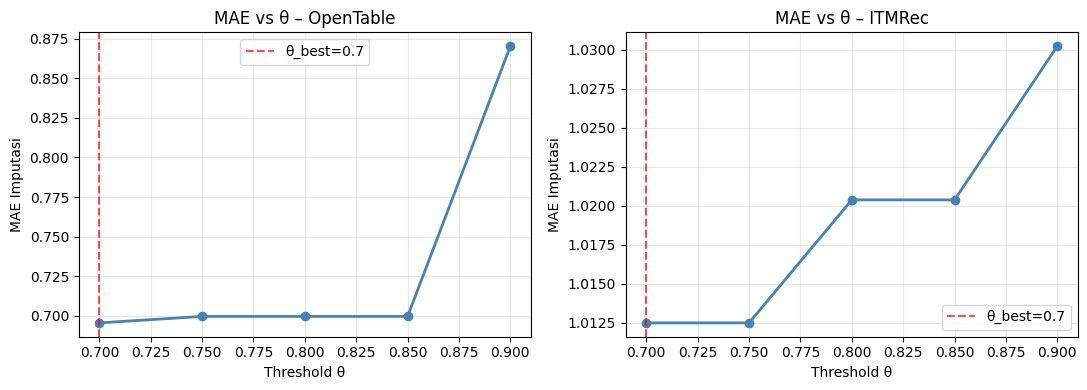

In [7]:
# BAGIAN 6 – TUNING CONFIDENCE THRESHOLD (θ)

def evaluate_imputation(df_true, df_imputed, mask, criteria_cols):
    """MAE imputasi hanya pada sel yang disembunyikan (mask=True)."""
    maes = {}
    for col in criteria_cols:
        m = mask[col]
        if m.sum() == 0: continue
        maes[col] = mean_absolute_error(df_true.loc[m, col].values,
                                         df_imputed.loc[m, col].values)
    return maes


THETA_RANGE = [0.70, 0.75, 0.80, 0.85, 0.90]
results_theta = {"OpenTable": {}, "ITMRec": {}}

for ds_name, df_masked, df_raw, mask, criteria, order, ucol, icol in [
    ("OpenTable", df_ot, df_ot_raw, mask_ot, OT_CRITERIA, order_ot, OT_USER_COL, OT_ITEM_COL),
    ("ITMRec",   df_it, df_it_raw, mask_it, IT_CRITERIA, order_it, IT_USER_COL, IT_ITEM_COL),
]:
    print(f"\n{'='*52}\n  {ds_name}\n{'='*52}")
    tr_idx, te_idx = train_test_split(df_masked.index, test_size=0.2, random_state=SEED)
    df_tr   = df_masked.loc[tr_idx]
    df_te   = df_masked.loc[te_idx]
    df_true = df_raw.loc[te_idx]
    msk_te  = mask.loc[te_idx]

    for theta in THETA_RANGE:
        rnb    = RecurrentNaiveBayes(criteria_order=order, theta=theta)
        rnb.fit(df_tr)
        df_imp = rnb.transform(df_te)
        maes   = evaluate_imputation(df_true, df_imp, msk_te, criteria)
        avg    = np.mean(list(maes.values()))
        results_theta[ds_name][theta] = avg
        print(f"  θ={theta:.2f}  →  MAE imputasi: {avg:.4f}"
              f"  | {' '.join([f'{k}:{v:.3f}' for k,v in maes.items()])}")

best_theta_ot = min(results_theta["OpenTable"], key=results_theta["OpenTable"].get)
best_theta_it = min(results_theta["ITMRec"],    key=results_theta["ITMRec"].get)
print(f"\n θ terbaik  →  OpenTable: {best_theta_ot}  |  ITMRec: {best_theta_it}")

# ── Visualisasi ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, dname in [(axes[0],"OpenTable"), (axes[1],"ITMRec")]:
    thetas = list(results_theta[dname].keys())
    maes   = list(results_theta[dname].values())
    ax.plot(thetas, maes, marker='o', linewidth=2, color='steelblue')
    bt = thetas[np.argmin(maes)]
    ax.axvline(bt, color='red', ls='--', alpha=0.7, label=f"θ_best={bt}")
    ax.set_xlabel("Threshold θ"); ax.set_ylabel("MAE Imputasi")
    ax.set_title(f"MAE vs θ – {dname}"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("theta_tuning.png", dpi=120); plt.show()


In [8]:
print("\n  Perbandingan MAE Imputasi (θ=0.0 vs θ_best):")
for ds_name, order, df_masked, df_raw, mask, criteria, ucol, icol, best_theta in [
    ("OpenTable", order_ot, df_ot, df_ot_raw, mask_ot, OT_CRITERIA,
     OT_USER_COL, OT_ITEM_COL, best_theta_ot),
    ("ITMRec",    order_it, df_it, df_it_raw, mask_it, IT_CRITERIA,
     IT_USER_COL, IT_ITEM_COL, best_theta_it),
]:
    tr_idx, te_idx = train_test_split(df_masked.index, test_size=0.2, random_state=SEED)
    df_tr  = df_masked.loc[tr_idx]
    df_te  = df_masked.loc[te_idx]
    df_true_te = df_raw.loc[te_idx]
    msk_te = mask.loc[te_idx]

    # θ=0.0
    rnb0 = RecurrentNaiveBayes(criteria_order=order, theta=0.0)
    rnb0.fit(df_tr)
    mae0 = np.mean(list(evaluate_imputation(df_true_te,
                   rnb0.transform(df_te), msk_te, criteria).values()))

    # θ=best
    rnb_best = RecurrentNaiveBayes(criteria_order=order, theta=best_theta)
    rnb_best.fit(df_tr)
    mae_best = np.mean(list(evaluate_imputation(df_true_te,
                       rnb_best.transform(df_te), msk_te, criteria).values()))

    delta_pct = (mae0 - mae_best) / mae0 * 100
    print(f"  [{ds_name}]  θ=0.0 → MAE={mae0:.4f}  |  "
          f"θ={best_theta} → MAE={mae_best:.4f}  |  "
          f"Penurunan: {delta_pct:.1f}%")


  Perbandingan MAE Imputasi (θ=0.0 vs θ_best):
  [OpenTable]  θ=0.0 → MAE=0.6528  |  θ=0.7 → MAE=0.6955  |  Penurunan: -6.5%
  [ITMRec]  θ=0.0 → MAE=0.8140  |  θ=0.7 → MAE=1.0125  |  Penurunan: -24.4%


## ⚙️ Bagian 7 – Training RSVD per Kriteria

In [9]:
# BAGIAN 7 – TRAINING RSVD (per kriteria, kedua dataset)
# GridSearch 18 kombinasi × 3-fold = ~54 latihan per kriteria

# ── OpenTable ───────────────────────────────────────────────
print("="*52)
print("  RSVD GridSearch – OpenTable")
print("="*52)

rnb_ot_full = RecurrentNaiveBayes(criteria_order=order_ot, theta=best_theta_ot)
rnb_ot_full.fit(df_ot)
df_ot_imp = rnb_ot_full.transform(df_ot).copy()
df_ot_imp[OT_USER_COL] = df_ot[OT_USER_COL].values
df_ot_imp[OT_ITEM_COL] = df_ot[OT_ITEM_COL].values
df_ot_imp[OT_RATING]   = df_ot[OT_RATING].values

rsvd_models_ot, rsvd_params_ot = train_rsvd_per_criterion(
    df_ot_imp, OT_USER_COL, OT_ITEM_COL, OT_CRITERIA)

print("\nParameter terbaik OpenTable:")
for c, p in rsvd_params_ot.items():
    print(f"  {c:12s}: {p}")


  RSVD GridSearch – OpenTable
GridSearch RSVD untuk kriteria [Food] (18 kombinasi × 3-fold CV) ...
     Best CV-MAE: 0.6264  |  Params: {'lr': 0.005, 'n_factors': 100, 'reg': 0.1}
GridSearch RSVD untuk kriteria [Service] (18 kombinasi × 3-fold CV) ...
     Best CV-MAE: 0.6752  |  Params: {'lr': 0.005, 'n_factors': 100, 'reg': 0.02}
GridSearch RSVD untuk kriteria [Ambience] (18 kombinasi × 3-fold CV) ...
     Best CV-MAE: 0.6158  |  Params: {'lr': 0.005, 'n_factors': 20, 'reg': 0.02}
GridSearch RSVD untuk kriteria [Value] (18 kombinasi × 3-fold CV) ...
     Best CV-MAE: 0.6668  |  Params: {'lr': 0.005, 'n_factors': 100, 'reg': 0.02}

Parameter terbaik OpenTable:
  Food        : {'lr': 0.005, 'n_factors': 100, 'reg': 0.1}
  Service     : {'lr': 0.005, 'n_factors': 100, 'reg': 0.02}
  Ambience    : {'lr': 0.005, 'n_factors': 20, 'reg': 0.02}
  Value       : {'lr': 0.005, 'n_factors': 100, 'reg': 0.02}


In [10]:
# ── ITMRec ──────────────────────────────────────────────────
print("="*52)
print("  RSVD GridSearch – ITMRec")
print("="*52)

rnb_it_full = RecurrentNaiveBayes(criteria_order=order_it, theta=best_theta_it)
rnb_it_full.fit(df_it)
df_it_imp = rnb_it_full.transform(df_it).copy()
df_it_imp[IT_USER_COL] = df_it[IT_USER_COL].values
df_it_imp[IT_ITEM_COL] = df_it[IT_ITEM_COL].values
df_it_imp[IT_RATING]   = df_it[IT_RATING].values

rsvd_models_it, rsvd_params_it = train_rsvd_per_criterion(
    df_it_imp, IT_USER_COL, IT_ITEM_COL, IT_CRITERIA)

print("\nParameter terbaik ITMRec:")
for c, p in rsvd_params_it.items():
    print(f"  {c:12s}: {p}")


  RSVD GridSearch – ITMRec
GridSearch RSVD untuk kriteria [App] (18 kombinasi × 3-fold CV) ...
     Best CV-MAE: 0.8312  |  Params: {'lr': 0.005, 'n_factors': 100, 'reg': 0.1}
GridSearch RSVD untuk kriteria [Data] (18 kombinasi × 3-fold CV) ...
     Best CV-MAE: 0.7708  |  Params: {'lr': 0.005, 'n_factors': 20, 'reg': 0.1}
GridSearch RSVD untuk kriteria [Ease] (18 kombinasi × 3-fold CV) ...
     Best CV-MAE: 0.6950  |  Params: {'lr': 0.005, 'n_factors': 100, 'reg': 0.1}

Parameter terbaik ITMRec:
  App         : {'lr': 0.005, 'n_factors': 100, 'reg': 0.1}
  Data        : {'lr': 0.005, 'n_factors': 20, 'reg': 0.1}
  Ease        : {'lr': 0.005, 'n_factors': 100, 'reg': 0.1}


## Bagian 8 – Random Forest Aggregation + Pipeline Evaluasi

Pipeline lengkap:
1. **Train split (80%)** → fit RNB → hasilkan matriks imputasi → latih RF aggregator
2. **Test split (20%)** → transform RNB → prediksi RSVD per kriteria → RF prediksi R0
3. Hitung **MAE** dan **Macro F1-Score** lalu bandingkan dengan baseline


In [11]:
# BAGIAN 8 – RANDOM FOREST AGGREGATION & GRIDSEARCHCV


def train_rf_aggregator(X_train, y_train, cv=5, seed=42):
    """
    Latih RandomForestClassifier sebagai fungsi agregasi non-linear.
    GridSearchCV pada metrik Macro F1-Score.
    """
    param_grid_rf = {
        "n_estimators"    : [50, 100, 200],
        "max_depth"       : [10, 20, None],
        "min_samples_split": [2, 5, 10],
    }
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    gs  = __import__('sklearn.model_selection', fromlist=['GridSearchCV']).GridSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=seed),
        param_grid_rf, scoring="f1_macro", cv=skf, n_jobs=-1, verbose=0
    )
    gs.fit(X_train, y_train)
    return gs.best_estimator_, gs.best_params_, gs.best_score_


def evaluate_system(y_true, y_pred, name=""):
    """Hitung dan tampilkan MAE + Macro F1/Precision/Recall."""
    mae  = mean_absolute_error(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro",  zero_division=0)
    print(f"  {'─'*46}")
    print(f"  Sistem  : {name}")
    print(f"  MAE     : {mae:.4f}")
    print(f"  Macro F1: {f1:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}")
    return {"mae": mae, "f1": f1, "precision": prec, "recall": rec}


def run_pipeline(df_raw, df_masked, mask,
                 user_col, item_col, rating_col,
                 criteria, order, rsvd_models, theta_best,
                 dataset_name=""):
    """
    Pipeline end-to-end Baseline vs Proposed pada Train/Test 80:20.
    
    Baseline : RNB (θ=0.0) + Mean Aggregation (rata-rata kriteria)
    Proposed : RNB (θ=theta_best) + Random Forest Aggregation
    """
    print(f"\n{'='*55}")
    print(f"  PIPELINE: {dataset_name}")
    print(f"{'='*55}")

    tr_idx, te_idx = train_test_split(df_masked.index, test_size=0.2, random_state=SEED)
    df_tr     = df_masked.loc[tr_idx].reset_index(drop=True)
    df_te     = df_masked.loc[te_idx].reset_index(drop=True)
    df_te_raw = df_raw.loc[te_idx].reset_index(drop=True)
    mask_te   = mask.loc[te_idx].reset_index(drop=True)
    y_true    = df_te_raw[rating_col].values.astype(int)

    
    # A) BASELINE: RNB (θ=0) + Mean Aggregation
    print("\n[BASELINE] RNB (θ=0.0) + Mean Aggregation")
    rnb_b = RecurrentNaiveBayes(criteria_order=order, theta=0.0)
    rnb_b.fit(df_tr)
    df_imp_b = rnb_b.transform(df_te)
    df_imp_b[user_col]  = df_te[user_col].values
    df_imp_b[item_col]  = df_te[item_col].values

    df_pred_b = predict_criteria_rsvd(df_imp_b, user_col, item_col, criteria, rsvd_models)
    # Agregasi: rata-rata kriteria → bulatkan ke integer
    y_base = np.clip(np.round(df_pred_b[criteria].values.mean(axis=1)), 1, 5).astype(int)
    metrics_b = evaluate_system(y_true, y_base, "BASELINE – RNB(θ=0) + Mean Agg")

    
    # B) BASELINE 2: RNB (θ=0) + Linear Regression Aggregation
    print("\n[BASELINE 2] RNB (θ=0.0) + Linear Regression Aggregation")
    # Latih LinReg pada data training dengan imputasi baseline
    df_tr_imp_b = rnb_b.transform(df_tr).copy()
    X_lr_tr = df_tr_imp_b[criteria].values
    y_lr_tr = df_tr[rating_col].values.astype(int)

    lr_model = LinearRegression()
    lr_model.fit(X_lr_tr, y_lr_tr)

    X_lr_te = df_pred_b[criteria].values
    y_lr    = np.clip(np.round(lr_model.predict(X_lr_te)), 1, 5).astype(int)
    metrics_lr = evaluate_system(y_true, y_lr, "BASELINE2 – RNB(θ=0) + LinReg Agg")

    # C) PROPOSED: RNB + Confidence Threshold + Random Forest
    print(f"\n[PROPOSED] RNB (θ={theta_best}) + Random Forest Aggregation")
    rnb_p = RecurrentNaiveBayes(criteria_order=order, theta=theta_best)
    rnb_p.fit(df_tr)
    df_imp_p = rnb_p.transform(df_te)
    df_imp_p[user_col]  = df_te[user_col].values
    df_imp_p[item_col]  = df_te[item_col].values
    rnb_p.acceptance_summary()

    df_pred_p = predict_criteria_rsvd(df_imp_p, user_col, item_col, criteria, rsvd_models)

    # Latih RF pada data training
    df_tr_imp = rnb_p.transform(df_tr).copy()
    X_rf_tr   = df_tr_imp[criteria].values
    y_rf_tr   = df_tr[rating_col].values.astype(int)
    print("\n  GridSearchCV Random Forest Aggregation ...")
    rf_model, rf_params, rf_cv_f1 = train_rf_aggregator(X_rf_tr, y_rf_tr, cv=5)
    print(f"     Best params : {rf_params}")
    print(f"     Best CV F1  : {rf_cv_f1:.4f}")

    X_rf_te = df_pred_p[criteria].values
    y_prop  = rf_model.predict(X_rf_te).astype(int)
    metrics_p = evaluate_system(y_true, y_prop, f"PROPOSED – RNB(θ={theta_best}) + RF Agg")

    return {
        "baseline": metrics_b, "baseline_lr": metrics_lr, "proposed": metrics_p,
        "rf_model": rf_model, "rf_params": rf_params,
        "y_true": y_true, "y_base": y_base, "y_prop": y_prop,
    }


print("Pipeline dan fungsi evaluasi siap.")


Pipeline dan fungsi evaluasi siap.


In [12]:
# Pipeline OpenTable
from sklearn.model_selection import GridSearchCV  # pastikan import tersedia
results_ot = run_pipeline(
    df_raw=df_ot_raw, df_masked=df_ot, mask=mask_ot,
    user_col=OT_USER_COL, item_col=OT_ITEM_COL, rating_col=OT_RATING,
    criteria=OT_CRITERIA, order=order_ot,
    rsvd_models=rsvd_models_ot, theta_best=best_theta_ot,
    dataset_name="OpenTable"
)



  PIPELINE: OpenTable

[BASELINE] RNB (θ=0.0) + Mean Aggregation
  ──────────────────────────────────────────────
  Sistem  : BASELINE – RNB(θ=0) + Mean Agg
  MAE     : 0.7049
  Macro F1: 0.1730  |  Precision: 0.3088  |  Recall: 0.2462

[BASELINE 2] RNB (θ=0.0) + Linear Regression Aggregation
  ──────────────────────────────────────────────
  Sistem  : BASELINE2 – RNB(θ=0) + LinReg Agg
  MAE     : 0.6272
  Macro F1: 0.2066  |  Precision: 0.2877  |  Recall: 0.2579

[PROPOSED] RNB (θ=0.7) + Random Forest Aggregation
  [RNB θ=0.7] Acceptance rate per kriteria:
    Food        : ░░░░░░░░░░░░░░░░░░░░   0.0% (no features → mean)
    Service     : █████████░░░░░░░░░░░  47.7% 
    Ambience    : ████████████░░░░░░░░  60.2% 
    Value       : █████████████░░░░░░░  69.8% 

  GridSearchCV Random Forest Aggregation ...
     Best params : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
     Best CV F1  : 0.5645
  ──────────────────────────────────────────────
  Sistem  : PROPOSED – R

In [13]:
# ── Jalankan Pipeline ITMRec ─────────────────────────────────
results_it = run_pipeline(
    df_raw=df_it_raw, df_masked=df_it, mask=mask_it,
    user_col=IT_USER_COL, item_col=IT_ITEM_COL, rating_col=IT_RATING,
    criteria=IT_CRITERIA, order=order_it,
    rsvd_models=rsvd_models_it, theta_best=best_theta_it,
    dataset_name="ITMRec"
)



  PIPELINE: ITMRec

[BASELINE] RNB (θ=0.0) + Mean Aggregation
  ──────────────────────────────────────────────
  Sistem  : BASELINE – RNB(θ=0) + Mean Agg
  MAE     : 1.1740
  Macro F1: 0.0966  |  Precision: 0.2368  |  Recall: 0.2005

[BASELINE 2] RNB (θ=0.0) + Linear Regression Aggregation
  ──────────────────────────────────────────────
  Sistem  : BASELINE2 – RNB(θ=0) + LinReg Agg
  MAE     : 1.1730
  Macro F1: 0.0968  |  Precision: 0.2322  |  Recall: 0.1907

[PROPOSED] RNB (θ=0.7) + Random Forest Aggregation
  [RNB θ=0.7] Acceptance rate per kriteria:
    App         : ░░░░░░░░░░░░░░░░░░░░   0.0% (no features → mean)
    Data        : ░░░░░░░░░░░░░░░░░░░░   0.0% 
    Ease        : ██████░░░░░░░░░░░░░░  32.0% 

  GridSearchCV Random Forest Aggregation ...
     Best params : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
     Best CV F1  : 0.4833
  ──────────────────────────────────────────────
  Sistem  : PROPOSED – RNB(θ=0.7) + RF Agg
  MAE     : 1.0985
  Macro F1: 0

In [14]:
# EVALUASI TAMBAHAN – K-Fold Cross Validation (K=5)
# untuk memvalidasi stabilitas hasil

def run_kfold_pipeline(df_raw, df_masked, mask,
                       user_col, item_col, rating_col,
                       criteria, order, rsvd_models, theta_best,
                       dataset_name="", n_splits=5):

    from sklearn.model_selection import StratifiedKFold
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    y_all = df_masked[rating_col].values.astype(int)

    fold_base, fold_prop = [], []

    for fold, (tr_idx, te_idx) in enumerate(kf.split(df_masked, y_all)):
        df_tr     = df_masked.iloc[tr_idx].reset_index(drop=True)
        df_te     = df_masked.iloc[te_idx].reset_index(drop=True)
        df_te_raw = df_raw.iloc[te_idx].reset_index(drop=True)
        y_true    = df_te_raw[rating_col].values.astype(int)

        # Baseline
        rnb_b = RecurrentNaiveBayes(criteria_order=order, theta=0.0)
        rnb_b.fit(df_tr)
        df_imp_b = rnb_b.transform(df_te)
        df_imp_b[user_col] = df_te[user_col].values
        df_imp_b[item_col] = df_te[item_col].values
        df_pred_b = predict_criteria_rsvd(df_imp_b, user_col, item_col, criteria, rsvd_models)
        y_base = np.clip(np.round(df_pred_b[criteria].values.mean(axis=1)), 1, 5).astype(int)
        fold_base.append({
            "mae": mean_absolute_error(y_true, y_base),
            "f1":  f1_score(y_true, y_base, average="macro", zero_division=0)
        })

        # Proposed
        rnb_p = RecurrentNaiveBayes(criteria_order=order, theta=theta_best)
        rnb_p.fit(df_tr)
        df_imp_p = rnb_p.transform(df_te)
        df_imp_p[user_col] = df_te[user_col].values
        df_imp_p[item_col] = df_te[item_col].values
        df_pred_p = predict_criteria_rsvd(df_imp_p, user_col, item_col, criteria, rsvd_models)
        df_tr_imp = rnb_p.transform(df_tr).copy()
        X_rf_tr   = df_tr_imp[criteria].values
        y_rf_tr   = df_tr[rating_col].values.astype(int)
        rf_model, _, _ = train_rf_aggregator(X_rf_tr, y_rf_tr, cv=3)
        y_prop = rf_model.predict(df_pred_p[criteria].values).astype(int)
        fold_prop.append({
            "mae": mean_absolute_error(y_true, y_prop),
            "f1":  f1_score(y_true, y_prop, average="macro", zero_division=0)
        })

    print(f"\n{'='*55}")
    print(f"  K-FOLD (K={n_splits}) – {dataset_name}")
    print(f"{'='*55}")
    for label, folds in [("Baseline", fold_base), ("Proposed", fold_prop)]:
        maes = [f["mae"] for f in folds]
        f1s  = [f["f1"]  for f in folds]
        print(f"  {label:10s} | MAE: {np.mean(maes):.4f} ± {np.std(maes):.4f}"
              f"  | F1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


run_kfold_pipeline(
    df_raw=df_ot_raw, df_masked=df_ot, mask=mask_ot,
    user_col=OT_USER_COL, item_col=OT_ITEM_COL, rating_col=OT_RATING,
    criteria=OT_CRITERIA, order=order_ot,
    rsvd_models=rsvd_models_ot, theta_best=best_theta_ot,
    dataset_name="OpenTable"
)

run_kfold_pipeline(
    df_raw=df_it_raw, df_masked=df_it, mask=mask_it,
    user_col=IT_USER_COL, item_col=IT_ITEM_COL, rating_col=IT_RATING,
    criteria=IT_CRITERIA, order=order_it,
    rsvd_models=rsvd_models_it, theta_best=best_theta_it,
    dataset_name="ITMRec"
)


  K-FOLD (K=5) – OpenTable
  Baseline   | MAE: 0.7257 ± 0.0111  | F1: 0.1619 ± 0.0039
  Proposed   | MAE: 0.6609 ± 0.0113  | F1: 0.1951 ± 0.0055

  K-FOLD (K=5) – ITMRec
  Baseline   | MAE: 1.1765 ± 0.0124  | F1: 0.1057 ± 0.0049
  Proposed   | MAE: 1.0951 ± 0.0230  | F1: 0.1448 ± 0.0090


## Bagian 9 – Visualisasi & Ringkasan

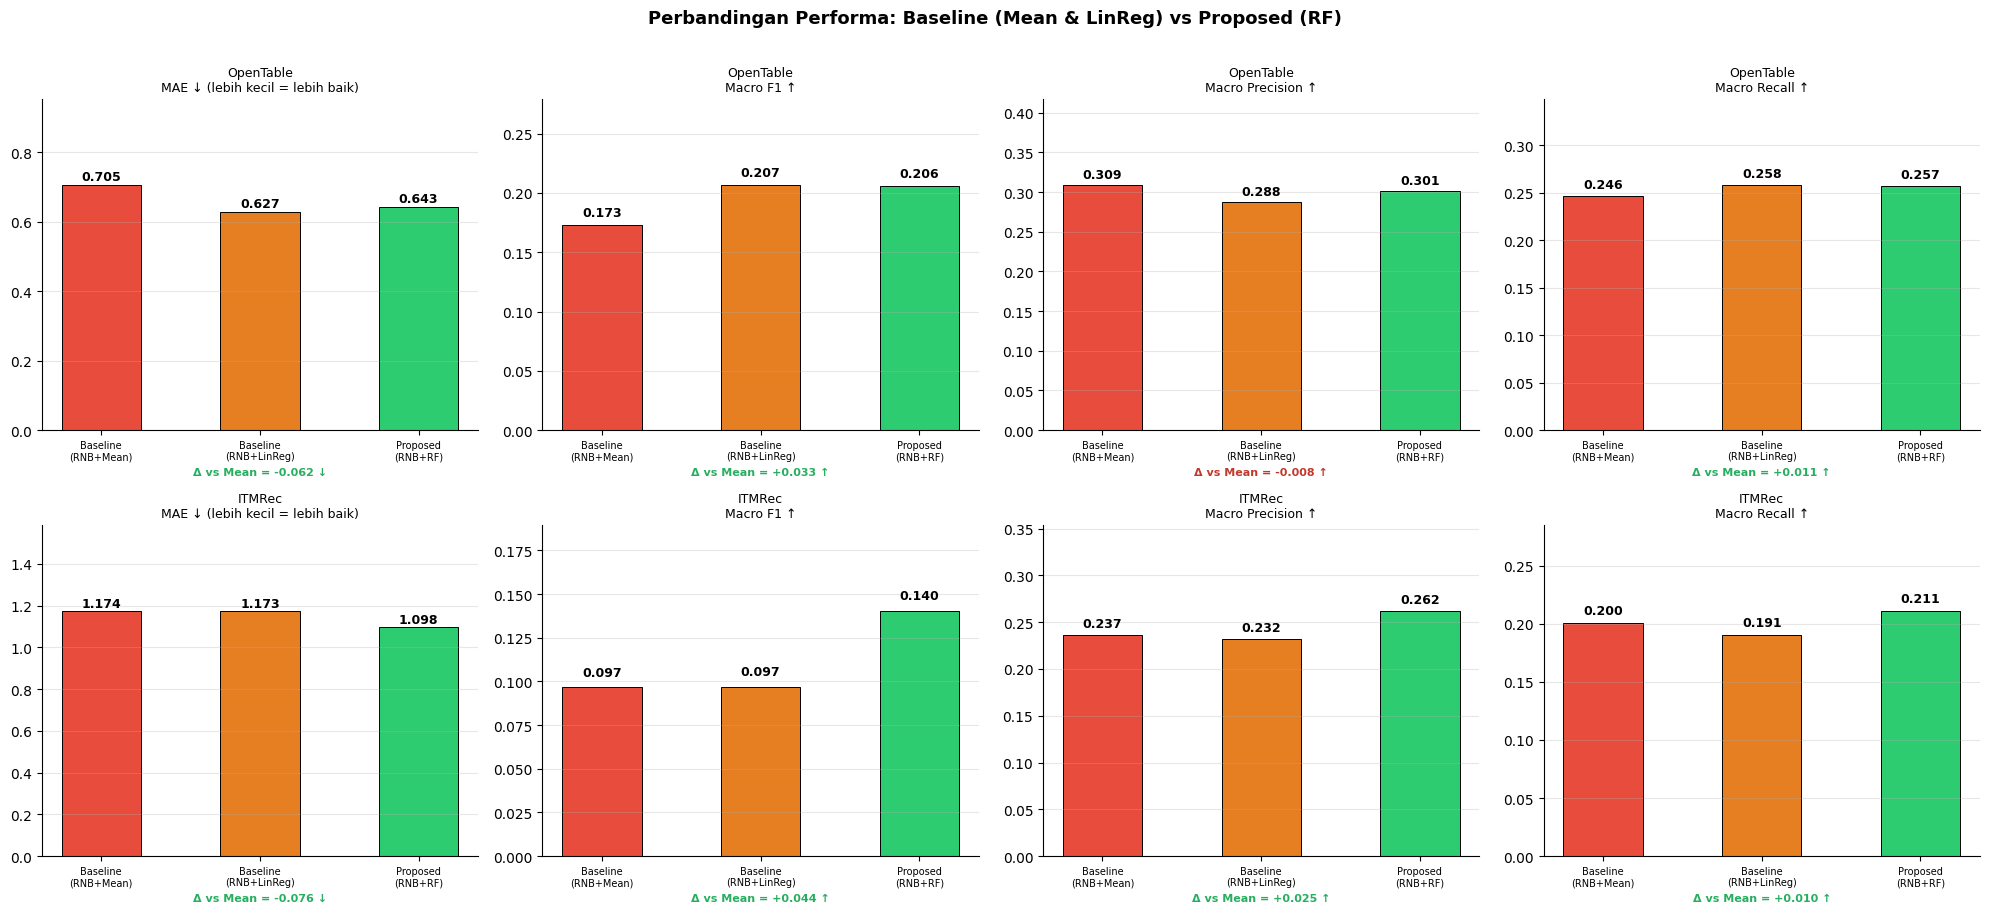

Plot disimpan ke comparison.png


In [15]:
# BAGIAN 9 – VISUALISASI KOMPARASI

def plot_comparison(results_ot, results_it):
    metrics = ["mae", "f1", "precision", "recall"]
    labels  = ["MAE ↓ (lebih kecil = lebih baik)",
               "Macro F1 ↑", "Macro Precision ↑", "Macro Recall ↑"]
    ds_list = [("OpenTable", results_ot), ("ITMRec", results_it)]

    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle("Perbandingan Performa: Baseline (Mean & LinReg) vs Proposed (RF)",
                 fontsize=13, fontweight="bold", y=1.01)

    for row, (ds, res) in enumerate(ds_list):
        for ci, (metric, label) in enumerate(zip(metrics, labels)):
            ax   = axes[row][ci]
            vals = [
                res["baseline"][metric],
                res["baseline_lr"][metric],
                res["proposed"][metric],
            ]
            clrs  = ["#e74c3c", "#e67e22", "#2ecc71"]
            xlbls = ["Baseline\n(RNB+Mean)", "Baseline\n(RNB+LinReg)", "Proposed\n(RNB+RF)"]
            bars  = ax.bar(xlbls, vals, color=clrs, width=0.5, edgecolor="black", lw=0.7)
            for b, v in zip(bars, vals):
                ax.text(b.get_x()+b.get_width()/2, v+0.005,
                        f"{v:.3f}", ha="center", va="bottom",
                        fontsize=9, fontweight="bold")
            ax.set_title(f"{ds}\n{label}", fontsize=9)
            ax.set_ylim(0, max(vals)*1.35 if max(vals) > 0 else 1)
            ax.grid(axis="y", alpha=0.3)
            ax.spines[["top","right"]].set_visible(False)
            ax.tick_params(axis='x', labelsize=7)

            # Delta Proposed vs Baseline Mean
            delta = vals[2] - vals[0]
            good  = (metric=="mae" and delta<0) or (metric!="mae" and delta>0)
            color = "#27ae60" if good else "#c0392b"
            sign  = "↓" if metric=="mae" else "↑"
            ax.set_xlabel(f"Δ vs Mean = {delta:+.3f} {sign}", color=color,
                          fontweight="bold", fontsize=8)

    plt.tight_layout()
    plt.savefig("comparison.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Plot disimpan ke comparison.png")


plot_comparison(results_ot, results_it)


In [16]:
# ── Tabel Ringkasan ──────────────────────────────────────────
rows = []
for ds, res in [("OpenTable", results_ot), ("ITMRec", results_it)]:
    for sys_label, key in [("Baseline (RNB+Mean)",   "baseline"),
                            ("Baseline (RNB+LinReg)", "baseline_lr"),
                            ("Proposed (RNB+RF)",     "proposed")]:
        r = res[key]
        rows.append({"Dataset": ds, "Sistem": sys_label,
                     "MAE": f"{r['mae']:.4f}", "Macro F1": f"{r['f1']:.4f}",
                     "Precision": f"{r['precision']:.4f}",
                     "Recall": f"{r['recall']:.4f}"})

df_summary = pd.DataFrame(rows)
print("\n" + "="*72)
print("  TABEL RINGKASAN PERBANDINGAN PERFORMA")
print("="*72)
print(df_summary.to_string(index=False))

print("\n" + "="*72)
print("  RINGKASAN PENINGKATAN (Proposed vs Baseline)")
print("="*72)
for ds, res in [("OpenTable", results_ot), ("ITMRec", results_it)]:
    b   = res["baseline"]
    blr = res["baseline_lr"]
    p   = res["proposed"]

    mae_d    = (b["mae"]   - p["mae"])   / b["mae"]          * 100
    f1_d     = (p["f1"]    - b["f1"])    / (b["f1"]   + 1e-9) * 100
    mae_d_lr = (blr["mae"] - p["mae"])   / blr["mae"]        * 100
    f1_d_lr  = (p["f1"]    - blr["f1"]) / (blr["f1"] + 1e-9) * 100

    print(f"\n  [{ds}] Proposed vs Baseline Mean:")
    print(f"    MAE : {b['mae']:.4f} → {p['mae']:.4f}  "
          f"({'↓' if mae_d>0 else '↑'}{abs(mae_d):.1f}%)")
    print(f"    F1  : {b['f1']:.4f} → {p['f1']:.4f}  "
          f"({'↑' if f1_d>0 else '↓'}{abs(f1_d):.1f}%)")

    print(f"  [{ds}] Proposed vs Baseline LinReg:")
    print(f"    MAE : {blr['mae']:.4f} → {p['mae']:.4f}  "
          f"({'↓' if mae_d_lr>0 else '↑'}{abs(mae_d_lr):.1f}%)")
    print(f"    F1  : {blr['f1']:.4f} → {p['f1']:.4f}  "
          f"({'↑' if f1_d_lr>0 else '↓'}{abs(f1_d_lr):.1f}%)")



  TABEL RINGKASAN PERBANDINGAN PERFORMA
  Dataset                Sistem    MAE Macro F1 Precision Recall
OpenTable   Baseline (RNB+Mean) 0.7049   0.1730    0.3088 0.2462
OpenTable Baseline (RNB+LinReg) 0.6272   0.2066    0.2877 0.2579
OpenTable     Proposed (RNB+RF) 0.6429   0.2056    0.3013 0.2573
   ITMRec   Baseline (RNB+Mean) 1.1740   0.0966    0.2368 0.2005
   ITMRec Baseline (RNB+LinReg) 1.1730   0.0968    0.2322 0.1907
   ITMRec     Proposed (RNB+RF) 1.0985   0.1402    0.2618 0.2109

  RINGKASAN PENINGKATAN (Proposed vs Baseline)

  [OpenTable] Proposed vs Baseline Mean:
    MAE : 0.7049 → 0.6429  (↓8.8%)
    F1  : 0.1730 → 0.2056  (↑18.9%)
  [OpenTable] Proposed vs Baseline LinReg:
    MAE : 0.6272 → 0.6429  (↑2.5%)
    F1  : 0.2066 → 0.2056  (↓0.5%)

  [ITMRec] Proposed vs Baseline Mean:
    MAE : 1.1740 → 1.0985  (↓6.4%)
    F1  : 0.0966 → 0.1402  (↑45.2%)
  [ITMRec] Proposed vs Baseline LinReg:
    MAE : 1.1730 → 1.0985  (↓6.4%)
    F1  : 0.0968 → 0.1402  (↑44.8%)


In [17]:
# ── Classification Report Detail ─────────────────────────────
for ds, res in [("OpenTable", results_ot), ("ITMRec", results_it)]:
    print("\n" + "="*60)
    print(f"  CLASSIFICATION REPORT – {ds} (PROPOSED)")
    print("="*60)
    print(classification_report(res["y_true"], res["y_prop"],
                                 labels=[1,2,3,4,5], zero_division=0))



  CLASSIFICATION REPORT – OpenTable (PROPOSED)
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        25
           2       0.00      0.00      0.00        59
           3       0.40      0.03      0.06       127
           4       0.25      0.81      0.39       265
           5       0.85      0.44      0.58       798

    accuracy                           0.45      1274
   macro avg       0.30      0.26      0.21      1274
weighted avg       0.63      0.45      0.45      1274


  CLASSIFICATION REPORT – ITMRec (PROPOSED)
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       134
           2       0.25      0.12      0.16       224
           3       0.11      0.44      0.17       116
           4       0.28      0.49      0.36       262
           5       0.67      0.01      0.01       310

    accuracy                           0.20      1046
   macro avg       0.26      0.21     

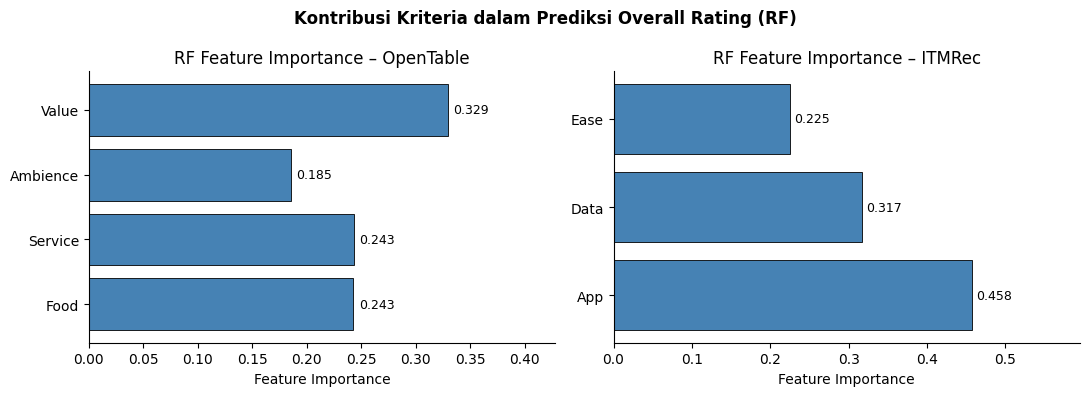

In [18]:
# ── Feature Importance RF ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, res, crit, title in [(axes[0], results_ot, OT_CRITERIA, "OpenTable"),
                              (axes[1], results_it, IT_CRITERIA, "ITMRec")]:
    imp  = res["rf_model"].feature_importances_
    bars = ax.barh(crit, imp, color="steelblue", edgecolor="black", lw=0.6)
    for b, v in zip(bars, imp):
        ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.3f}",
                va="center", fontsize=9)
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"RF Feature Importance – {title}")
    ax.set_xlim(0, max(imp)*1.3)
    ax.spines[["top","right"]].set_visible(False)
plt.suptitle("Kontribusi Kriteria dalam Prediksi Overall Rating (RF)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120); plt.show()
